In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [3]:
X,y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

In [4]:
df=pd.DataFrame(X, columns=['Feature 1', 'Feature 2'])
df

,Feature 1,Feature 2
0,0.836857,2.136359
1,-1.413658,7.409623
2,1.155213,5.099619
3,-1.018616,7.814915
4,1.271351,1.892542
...,...,...
295,1.973698,1.579798
296,2.518342,1.391766
297,0.438990,4.535929
298,0.369479,7.791105


In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [6]:
WCSS = []  #inertia values for different k values
k_values = range(1, 11)  #k values from 1 to 10

In [7]:
for K in k_values:
    kmeans = KMeans(n_clusters=K, random_state=42)
    kmeans.fit(X_scaled)
    WCSS.append(kmeans.inertia_)
    

In [8]:
WCSS

[600.0,
 270.3431137506443,
 191.27421726522257,
 56.02477057509951,
 49.448585387935644,
 42.64361661581211,
 36.89826153519394,
 29.491821088221286,
 28.164080730057208,
 26.37569060444804]

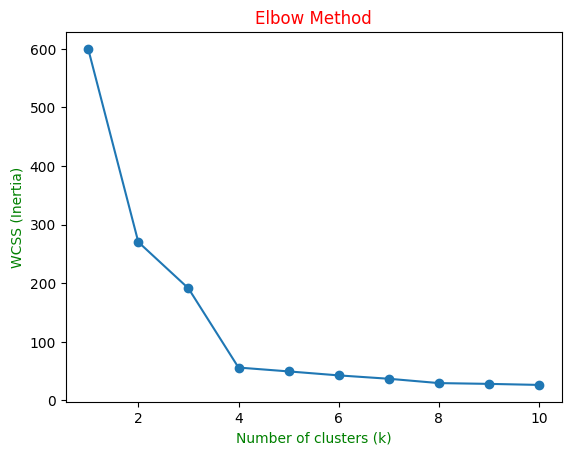

In [12]:
plt.plot(k_values, WCSS, marker='o')
plt.title('Elbow Method',color="red")
plt.xlabel('Number of clusters (k)',color="green")
plt.ylabel('WCSS (Inertia)',color="green")
plt.show()


In [14]:
k_means_final = KMeans(n_clusters=4, random_state=42)

In [16]:
cluster_labels = k_means_final.fit_predict(X_scaled)
cluster_labels

array([0, 1, 2, 1, 0, 0, 3, 2, 1, 1, 3, 1, 2, 1, 0, 2, 2, 0, 3, 3, 0, 0,
       2, 3, 3, 2, 0, 2, 3, 2, 1, 1, 2, 1, 1, 1, 1, 1, 3, 0, 2, 3, 2, 2,
       3, 3, 1, 3, 1, 0, 3, 0, 1, 0, 0, 3, 1, 3, 1, 0, 1, 2, 1, 3, 3, 3,
       1, 0, 1, 3, 2, 3, 1, 3, 3, 1, 3, 2, 0, 1, 0, 2, 0, 0, 1, 2, 0, 2,
       1, 1, 2, 0, 1, 3, 3, 2, 0, 0, 2, 3, 1, 0, 1, 0, 2, 0, 0, 2, 1, 2,
       3, 3, 0, 1, 0, 2, 1, 0, 0, 2, 3, 0, 3, 0, 0, 0, 0, 3, 0, 3, 1, 3,
       3, 0, 1, 3, 3, 1, 2, 1, 1, 3, 2, 3, 2, 3, 1, 2, 1, 1, 1, 2, 1, 2,
       0, 3, 1, 3, 0, 2, 1, 2, 2, 0, 2, 3, 3, 2, 0, 2, 2, 1, 0, 2, 3, 1,
       0, 0, 2, 3, 0, 2, 3, 3, 2, 2, 2, 2, 0, 1, 2, 3, 2, 2, 3, 3, 3, 2,
       3, 1, 2, 3, 0, 3, 2, 1, 3, 1, 2, 1, 2, 3, 2, 2, 1, 3, 3, 0, 0, 2,
       1, 0, 0, 3, 0, 3, 2, 1, 1, 2, 2, 1, 2, 0, 3, 2, 0, 3, 1, 3, 0, 2,
       0, 1, 1, 1, 1, 3, 3, 1, 2, 3, 0, 2, 3, 3, 3, 0, 0, 1, 2, 2, 3, 0,
       1, 3, 2, 1, 2, 0, 0, 3, 3, 2, 0, 0, 0, 2, 1, 1, 0, 0, 2, 0, 0, 0,
       1, 3, 1, 2, 0, 0, 1, 1, 1, 0, 0, 2, 1, 3], d

In [17]:
df['Cluster'] = cluster_labels

<Axes: xlabel='Feature 1', ylabel='Feature 2'>

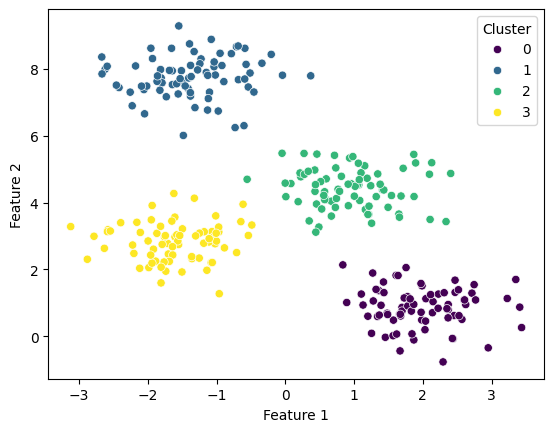

In [21]:
sns.scatterplot(data=df, x='Feature 1', y='Feature 2', hue='Cluster', palette='viridis')